# Board Game Data Exploration

In [1]:
from src.db import connect, load_board_games
from src.preprocess import preprocess
from src.visualize import (
    plot_feature_distributions,
    plot_top_categories_and_mechanics,
    plot_rating_vs_weight,
    plot_games_per_decade,
    plot_rating_tiers,
    plot_correlation_matrix,
    plot_mechanic_vs_rating,
)

engine = connect()
raw_df = load_board_games(engine)
print(f"Raw: {len(raw_df)} games")

df = preprocess(raw_df)
print(f"After preprocessing: {len(df)} games")

Raw: 103035 games
After preprocessing: 30390 games


In [2]:
df.describe()

,bgg_id,year_published,min_players,max_players,min_playtime,max_playtime,playing_time,min_age,average_rating,bayes_average_rating,users_rated,average_weight,playtime_range,player_range,category_count,mechanic_count,decade
count,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000,30390.000000
mean,180687.103949,2010.832478,1.943468,5.907667,52.098717,76.885949,76.885949,9.745936,6.513402,5.670580,954.223264,1.936542,24.787233,3.964199,2.672985,3.385489,2006.398157
std,142305.404871,13.796436,0.712124,10.750842,72.646329,131.922775,131.922775,3.636306,0.923260,0.345850,4308.055644,0.831841,98.540176,10.698121,1.388692,2.592823,14.150210
min,1.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.263850,3.866890,30.000000,0.000000,-720.000000,-6.000000,0.000000,0.000000,1900.000000
25%,26794.250000,2006.000000,2.000000,4.000000,20.000000,25.000000,25.000000,8.000000,5.941290,5.509890,57.000000,1.250000,0.000000,2.000000,2.000000,2.000000,2000.000000
50%,176986.000000,2015.000000,2.000000,4.000000,30.000000,45.000000,45.000000,10.000000,6.542700,5.538145,127.000000,1.875000,0.000000,3.000000,2.000000,3.000000,2010.000000
75%,299783.250000,2020.000000,2.000000,6.000000,60.000000,90.000000,90.000000,12.000000,7.127455,5.650755,415.000000,2.479975,20.000000,4.000000,3.000000,5.000000,2020.000000
max,465819.000000,2027.000000,10.000000,100.000000,1440.000000,1440.000000,1440.000000,21.000000,9.843750,8.470760,141504.000000,4.816300,1435.000000,99.000000,17.000000,27.000000,2020.000000


## Feature Distributions

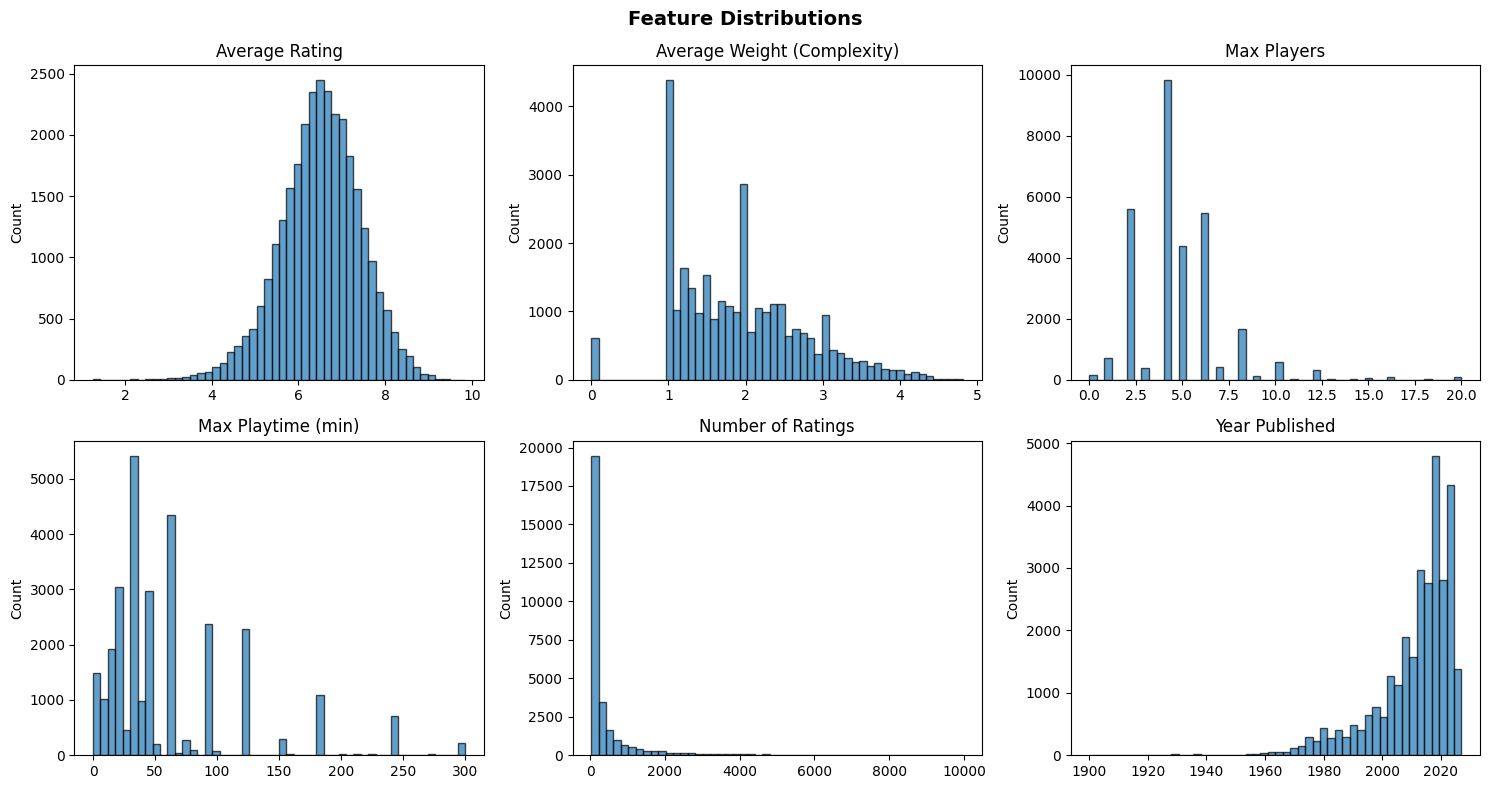

In [3]:
plot_feature_distributions(df)

## Category & Mechanic Frequency

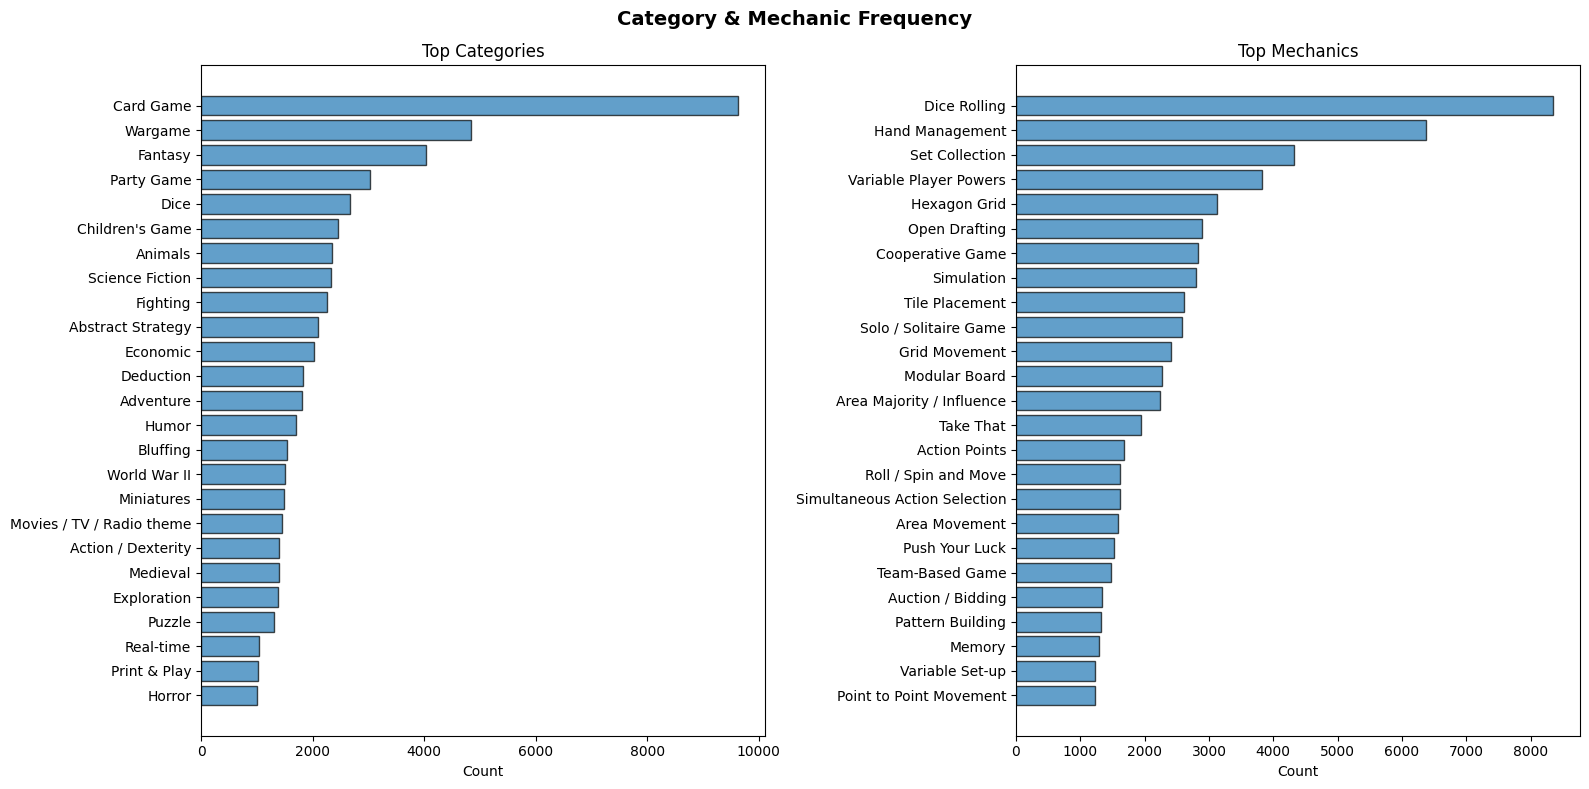

In [4]:
plot_top_categories_and_mechanics(df)

## Rating vs Complexity

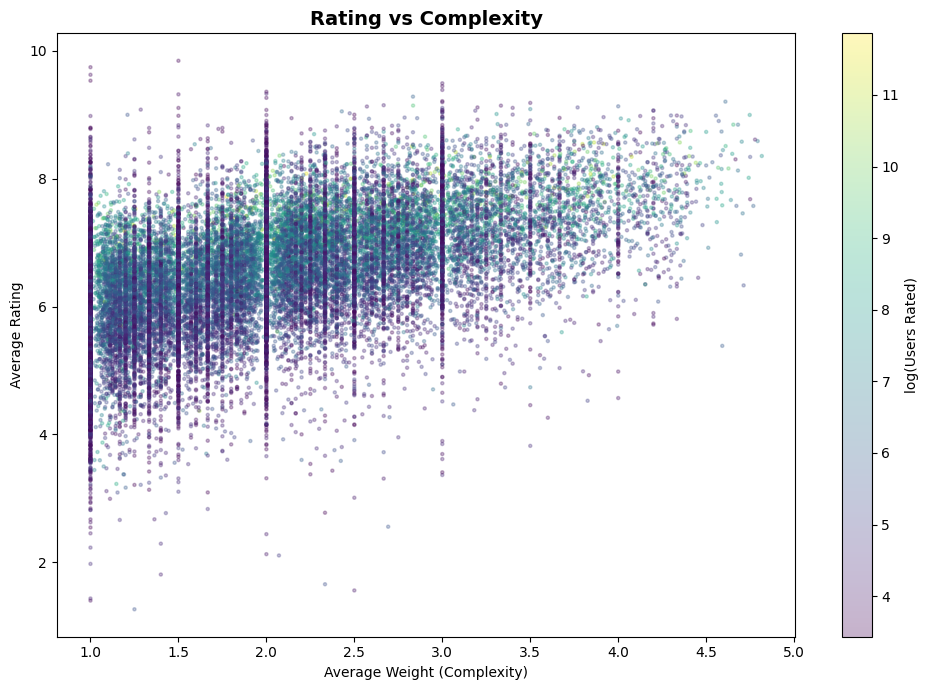

In [5]:
plot_rating_vs_weight(df)

## Feature Correlations

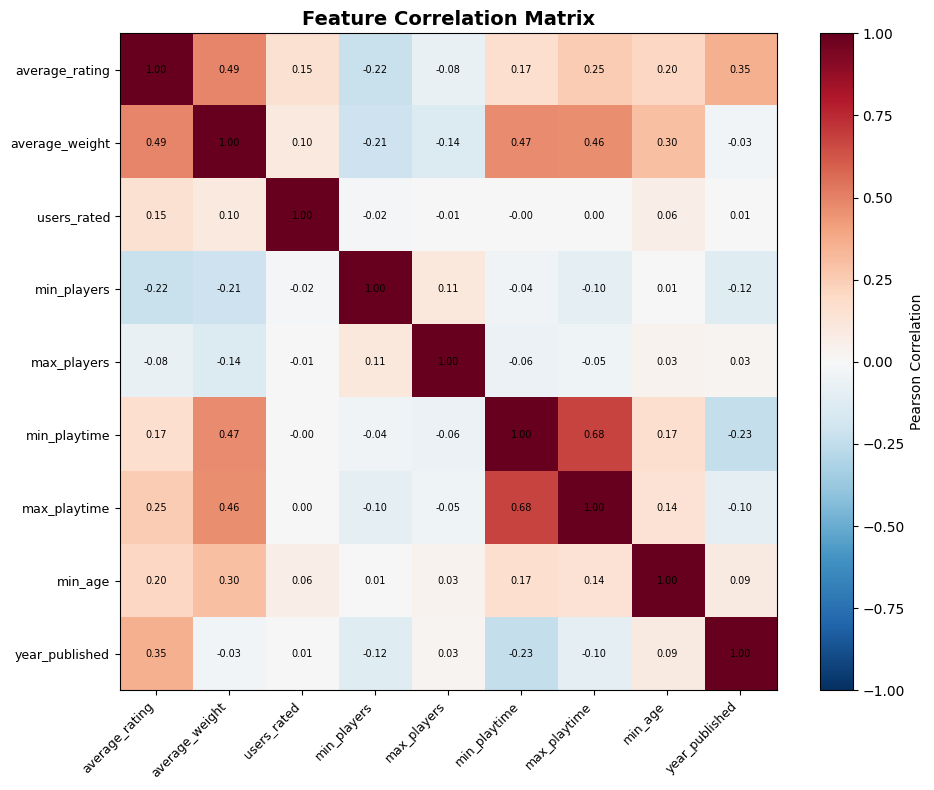

In [6]:
plot_correlation_matrix(df)

## Rating by Mechanic

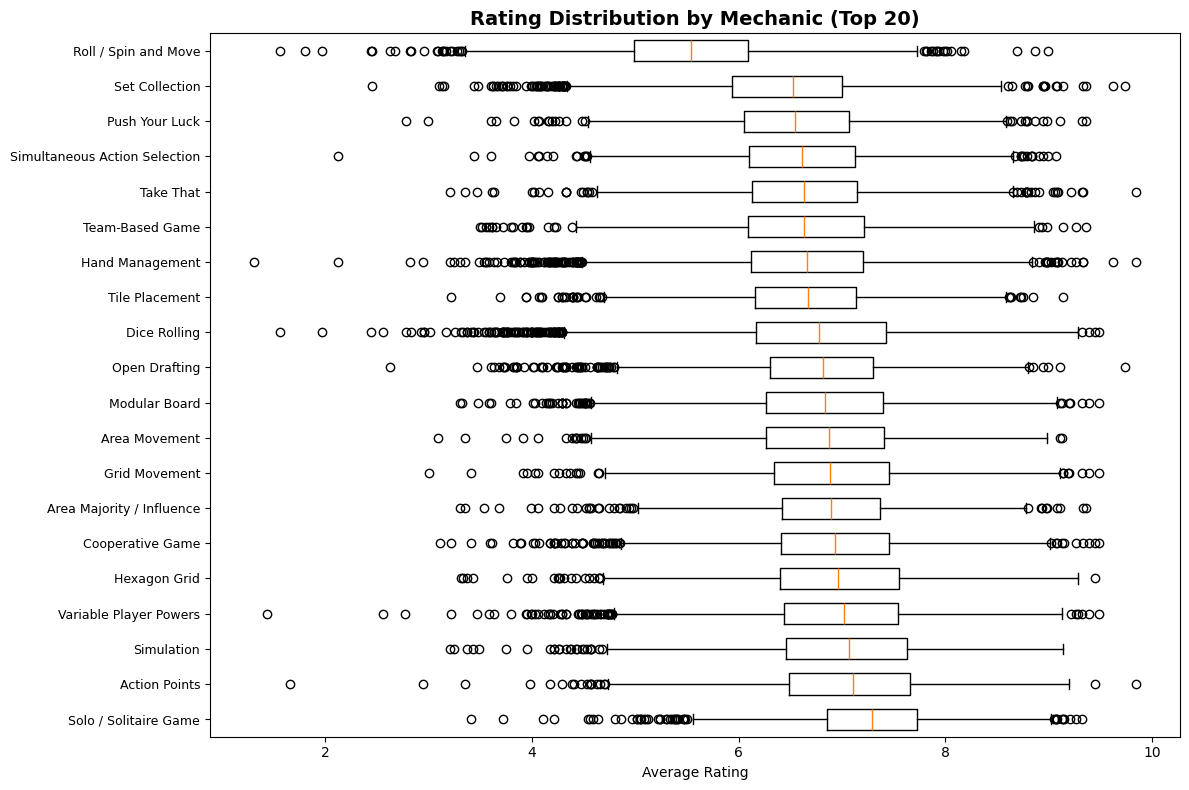

In [7]:
plot_mechanic_vs_rating(df)

## Content-Based Recommendations

Testing with 3 very different games:
- **Catan** (bgg_id=13) — classic gateway, negotiation/trading
- **Gloomhaven** (bgg_id=174430) — heavy cooperative dungeon crawler
- **Codenames** (bgg_id=178900) — light party/word game

In [8]:
from src.engine import RecommendationEngine

rec = RecommendationEngine(engine)
rec.load(min_ratings=30)
print(f"Engine loaded with {rec.game_count} games")

Engine loaded with 30390 games


In [9]:
import pandas as pd

test_games = [
    (13, "Catan"),
    (174430, "Gloomhaven"),
    (178900, "Codenames"),
]

for bgg_id, label in test_games:
    results = rec.recommend(bgg_id, top_n=20)
    if not results:
        print(f"\n{label} (bgg_id={bgg_id}): NOT FOUND in dataset\n")
        continue

    results_df = pd.DataFrame(results)
    results_df.index = range(1, len(results_df) + 1)
    results_df.index.name = "rank"
    print(f"\n{'='*60}")
    print(f"Top 20 similar to: {label} (bgg_id={bgg_id})")
    print(f"{'='*60}")
    display(results_df)


Top 20 similar to: Catan (bgg_id=13)


,bgg_id,name,score
rank,,,
1,451387,Catan Connect,0.785383
2,338697,Catan: 3D Edition,0.648774
3,305668,Catan: 25th Anniversary Edition,0.602692
4,298278,Catan: 25 Jahre Jubiläums-Edition,0.578128
5,182880,Catan: Big Box,0.448091
6,17419,Catan 3D Collector's Edition,0.448003
7,147240,Catan: Family Edition,0.439276
8,38821,Settlers of Catan: Gallery Edition,0.415615
9,24511,Simply Catan,0.415064



Top 20 similar to: Gloomhaven (bgg_id=174430)


,bgg_id,name,score
rank,,,
1,390478,Gloomhaven (Second Edition),0.878574
2,295770,Frosthaven,0.818415
3,291457,Gloomhaven: Jaws of the Lion,0.809329
4,322524,Bardsung,0.674163
5,169427,Middara: Unintentional Malum – Act 1,0.652332
6,273814,Deliverance,0.623932
7,352225,Terminus Frontier,0.619848
8,320255,Pericle: Gathering Darkness,0.607062
9,393672,Gloomhaven: Buttons & Bugs,0.576777



Top 20 similar to: Codenames (bgg_id=178900)


,bgg_id,name,score
rank,,,
1,450782,Codenames: Back to Hogwarts,0.658339
2,224037,Codenames: Duet,0.643951
3,205158,Codenames: Deep Undercover,0.642654
4,198773,Codenames: Pictures,0.620560
5,301628,Codenames: Blizzard Edition,0.589943
6,225694,Decrypto,0.582604
7,339975,The Game of Fuzzy Logic,0.562623
8,452572,Out of Words,0.546135
9,147151,Concept,0.545735
